In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("disease.csv")
df.head()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Shuffle data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,70.0,1.020,0.0,0.0,1.0,57.0,3.07,137.53,4.63,11.5,6900.0,4.71,0.0,1
1,80.0,1.020,1.0,0.0,1.0,33.0,0.90,144.00,4.50,13.3,8100.0,5.20,0.0,0
2,100.0,1.020,2.0,0.0,0.0,55.0,2.50,137.53,4.63,10.1,8406.0,4.71,1.0,1
3,100.0,1.015,4.0,2.0,1.0,132.0,12.80,135.00,5.70,7.3,9800.0,3.90,1.0,1
4,100.0,1.010,3.0,2.0,0.0,90.0,5.60,140.00,2.90,9.2,7000.0,3.20,1.0,1


In [ ]:
le = LabelEncoder()

df['Rbc'] = le.fit_transform(df['Rbc'])
df['Htn'] = le.fit_transform(df['Htn'])
df['Class'] = le.fit_transform(df['Class'])

In [ ]:
df.fillna(df.mean(), inplace=True)

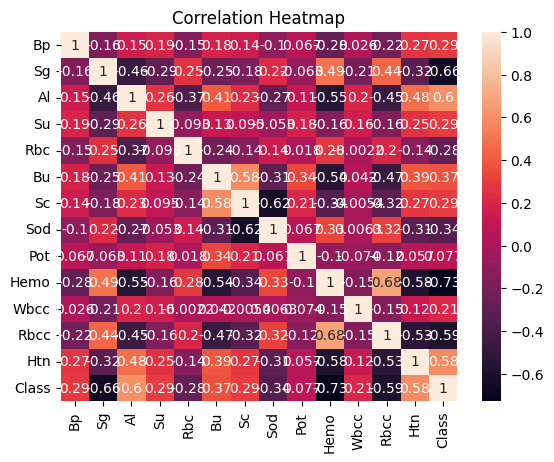

In [ ]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,      # VERY IMPORTANT
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000, C=0.1)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.9833333333333333


In [ ]:
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.975


In [ ]:
cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average Accuracy (FINAL):", cv_scores.mean())

Cross Validation Scores: [0.9875 0.9875 0.9375 0.9875 0.925 ]
Average Accuracy (FINAL): 0.9650000000000001


In [ ]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy :", rf.score(X_test, y_test))

Train Accuracy: 0.975
Test Accuracy : 0.975


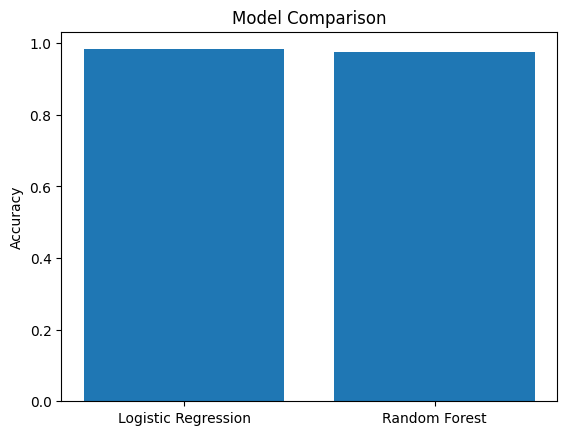

In [ ]:
models = ["Logistic Regression", "Random Forest"]
accuracies = [acc_lr, acc_rf]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

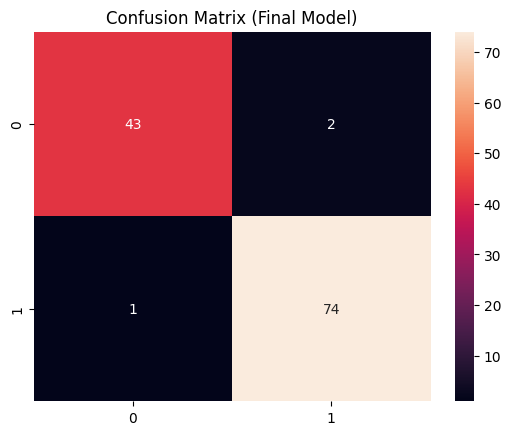

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Final Model)")
plt.show()

In [ ]:
final_model = rf
print("Final Model: Random Forest (Tuned)")

Final Model: Random Forest (Tuned)


In [ ]:
def predict_kidney(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)

    result = final_model.predict(input_data)[0]
    prob = final_model.predict_proba(input_data)[0][1]

    if result == 1:
        print("⚠️ HIGH RISK")
        print("Probability:", round(prob*100,2), "%")
    else:
        print("✅ LOW RISK")
        print("Probability:", round(prob*100,2), "%")

In [ ]:
sample = [180, 1.02, 1, 0, 1, 40, 1.2, 190, 6.5, 15, 80000, 5.0, 5]

predict_kidney(sample)

⚠️ HIGH RISK
Probability: 51.24 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.9650000000000001
